# Using Bifurcations to Switch Between Point Attractors and Limit Cycles

**Course project based on:**  
Farshad Khadivar, Ilaria Lauzana, and Aude Billard,  
*Learning Dynamical Systems with Bifurcations*, Robotics and Autonomous Systems.

## Project Motivation

In this project, I study how a single nonlinear dynamical system can generate two different types of robot motion: point-to-point motion and rhythmic motion. I chose this paper because it gives a practical robotics application of several concepts covered in class, especially equilibrium points, stability, phase portraits, limit cycles, bifurcations, and switched systems.

The main question I investigate is:

> **Can one dynamical system change from a stable point attractor to a stable limit cycle by varying only one interpretable parameter?**

This question is important in robotics because many tasks naturally combine both behaviors. For example, a robot may first move toward an object and then perform a repeated motion such as wiping or polishing. A simple approach would be to use one controller for reaching and another controller for rhythmic motion. However, switching between two separate dynamical systems can produce abrupt velocity changes and jerky motion.

The paper proposes a different idea: instead of switching between separate controllers, both behaviors are embedded inside one parameterized dynamical system. By changing a bifurcation-like parameter, the same system can smoothly transition between a point attractor and a limit cycle.

In my replication, I focus on the core nonlinear-dynamics mechanism and its robotic interpretation. I first analyze the simplified 2D system through stability analysis, phase portraits, parameter sweeps, and a comparison between hard switching and smooth parameter switching. Then, I connect the analysis to robotics by implementing a MuJoCo simulation study with the Franka Research 3 robot, where the dynamical system is used to generate reference end-effector motion.

## 1. Motivation

Robotic motion often contains two different behaviors:

- **Point-to-point motion:** reaching, moving to a target, pick-and-place.
- **Rhythmic motion:** wiping, polishing, walking, drumming.

A common approach is to model these with separate dynamical systems and switch between them online. The paper argues that hard switching can create discontinuities, jerky velocity profiles, and possible instability when the systems have different attractors. The proposed solution is to encode both behaviors in one parameterized dynamical system, so changing a parameter changes the behavior without replacing the controller.

### 1.1 Course Concepts Used in This Project

Before implementing the paper, I first identified the nonlinear dynamics concepts from class that appear in this work. The paper is useful for my project because it gives a robotics application of several core ideas:

1. Equilibrium point: when the target radius is zero, the system behaves like a stable point attractor.
2. Stability: the radial error decays exponentially, so I can directly connect the model to asymptotic stability.
3. Phase portrait: by plotting trajectories from different initial conditions, I can visualize the vector field and attraction behavior.
4. Limit cycle: when the target radius is nonzero, the trajectory does not converge to a point; it converges to a closed orbit.
5. Bifurcation: changing the radius parameter changes the qualitative long-term behavior of the system.
6. Switched systems: the paper motivates why switching between different dynamical systems can create jerky transients.
7. System identification: the learning part of the paper estimates model parameters from demonstration data.

Therefore, I am not treating the paper only as a robotics-control paper. I am using it as a case study to understand how concepts from nonlinear dynamical systems can be used to generate robot motion.

## 2. Classical Hopf Bifurcation and Paper Formulation

### 2.1 Connection to the Classical Hopf Bifurcation

A standard supercritical Hopf bifurcation can be written in polar coordinates as

$$
\dot{r} = \mu r - r^3, \qquad \dot{\theta}=\omega.
$$

For this classical Hopf normal form:

- If `mu < 0`, the origin `r=0` is stable.
- If `mu > 0`, a stable limit cycle appears at `r = sqrt(mu)`.

This is the class concept of a **Hopf bifurcation**: changing a bifurcation parameter changes the qualitative long-term behavior from an equilibrium to a periodic orbit.

The paper does not directly use the classical Hopf normal form. Instead, it designs a Hopf-inspired system where the target radius `rho0` directly controls whether the system behaves as a point attractor or a limit cycle. This makes the controller easier to modulate in robotics, because the cycle radius, center, orientation, and rotation speed can be changed explicitly.

### 2.2 Numerical Comparison with Classical Hopf Bifurcation

To make the connection with the course concept more explicit, I first simulated the classical Hopf normal form before using the paper's modified dynamical system. The classical supercritical Hopf bifurcation in polar coordinates is

$$
\dot{r} = \mu r - r^3, \qquad \dot{\theta} = \omega.
$$

This gives the following behavior:

- For $\mu < 0$, the origin is stable.
- For $\mu = 0$, the system is at the bifurcation value.
- For $\mu > 0$, a stable limit cycle appears with radius $r^* = \sqrt{\mu}$.

This is the standard course idea of a Hopf bifurcation: changing a parameter changes the qualitative long-term behavior of the phase portrait. The paper uses the same idea, but modifies the parameterization for robotics. Instead of using $\mu$, the paper uses $\rho_0$, where the final orbit radius is directly controlled as

$$
\rho^* = \rho_0.
$$

Therefore, the classical Hopf model is useful for understanding the theory, while the paper's model is useful for robot motion generation because the radius of the cyclic motion can be commanded directly.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


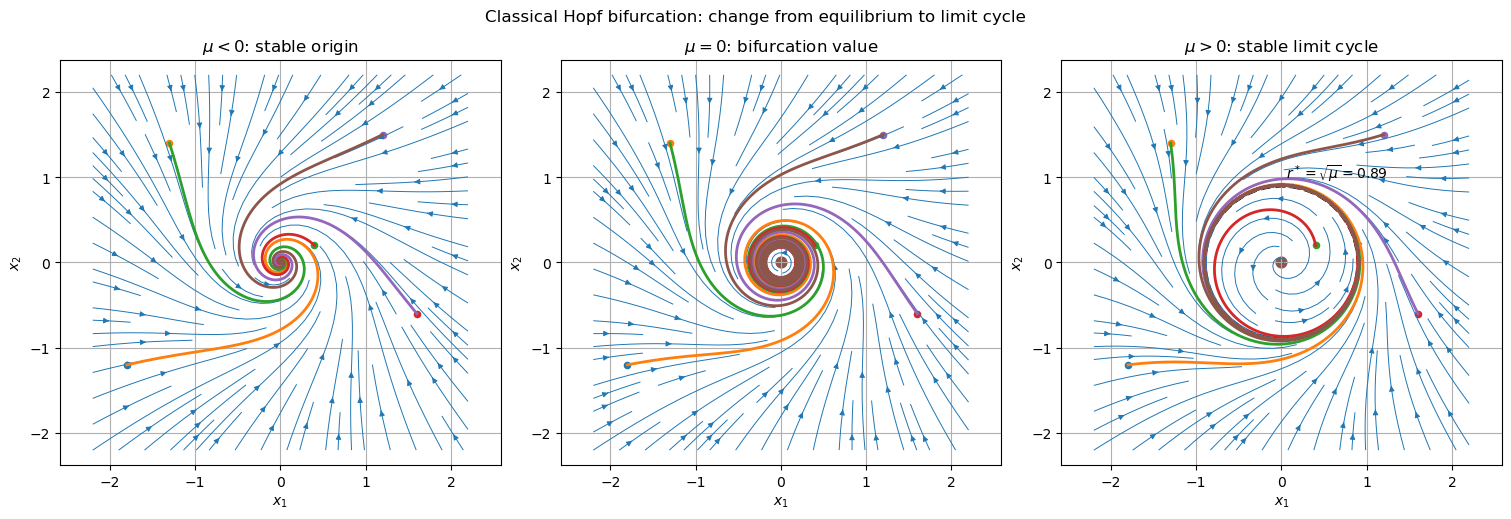

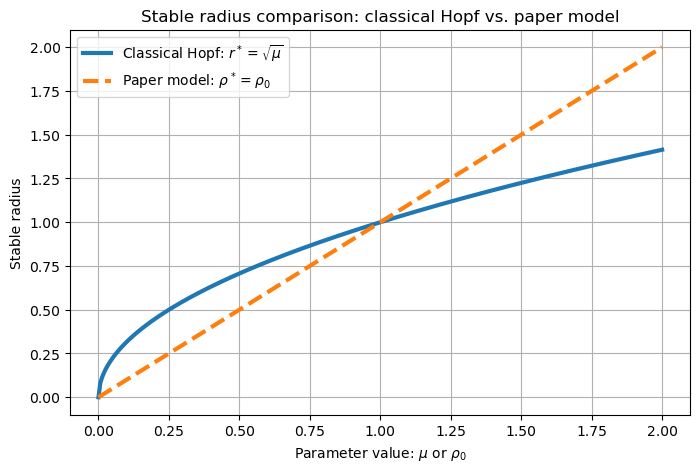

In [3]:
# Numerical comparison: classical Hopf normal form vs. paper's radius parameterization

import numpy as np
import matplotlib.pyplot as plt

def hopf_cartesian(x, mu=1.0, omega=2.0):
    """
    Classical supercritical Hopf normal form in Cartesian coordinates.

    Polar form:
        r_dot = mu*r - r^3
        theta_dot = omega

    Cartesian form:
        x_dot = (mu - r^2)x - omega*y
        y_dot = omega*x + (mu - r^2)y
    """
    x1, x2 = x
    r2 = x1**2 + x2**2

    dx1 = (mu - r2) * x1 - omega * x2
    dx2 = omega * x1 + (mu - r2) * x2

    return np.array([dx1, dx2])


def simulate_hopf(x0, mu=1.0, omega=2.0, dt=0.01, steps=3000):
    xs = np.zeros((steps + 1, 2))
    xs[0] = np.asarray(x0, dtype=float)

    for k in range(steps):
        xs[k + 1] = xs[k] + dt * hopf_cartesian(xs[k], mu=mu, omega=omega)

    return xs


# Initial conditions for phase portraits
initial_conditions = [
    (-1.8, -1.2),
    (-1.3, 1.4),
    (0.4, 0.2),
    (1.6, -0.6),
    (1.2, 1.5),
]

mu_cases = [-0.5, 0.0, 0.8]
case_titles = [
    r"$\mu < 0$: stable origin",
    r"$\mu = 0$: bifurcation value",
    r"$\mu > 0$: stable limit cycle",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

for ax, mu, title in zip(axes, mu_cases, case_titles):

    # Vector field grid
    x_grid = np.linspace(-2.2, 2.2, 25)
    y_grid = np.linspace(-2.2, 2.2, 25)
    X, Y = np.meshgrid(x_grid, y_grid)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            vel = hopf_cartesian([X[i, j], Y[i, j]], mu=mu, omega=2.0)
            U[i, j] = vel[0]
            V[i, j] = vel[1]

    ax.streamplot(X, Y, U, V, density=1.0, linewidth=0.7, arrowsize=0.8)

    # Simulated trajectories
    for x0 in initial_conditions:
        xs = simulate_hopf(x0, mu=mu, omega=2.0, dt=0.01, steps=2500)
        ax.plot(xs[:, 0], xs[:, 1], lw=2)
        ax.scatter(xs[0, 0], xs[0, 1], s=20)

    # Limit cycle radius for mu > 0
    if mu > 0:
        r_star = np.sqrt(mu)
        circle = plt.Circle((0, 0), r_star, fill=False, linestyle="--", linewidth=2)
        ax.add_patch(circle)
        ax.text(0.05, r_star + 0.1, rf"$r^*=\sqrt{{\mu}}={r_star:.2f}$")

    ax.scatter(0, 0, s=60)
    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.axis("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.grid(True)

plt.suptitle("Classical Hopf bifurcation: change from equilibrium to limit cycle", y=1.05)
plt.show()


# Amplitude/radius law comparison
mu_values = np.linspace(0, 2.0, 300)
classical_radius = np.sqrt(mu_values)

rho0_values = np.linspace(0, 2.0, 300)
paper_radius = rho0_values

plt.figure(figsize=(8, 5))
plt.plot(mu_values, classical_radius, lw=3, label=r"Classical Hopf: $r^*=\sqrt{\mu}$")
plt.plot(rho0_values, paper_radius, "--", lw=3, label=r"Paper model: $\rho^*=\rho_0$")
plt.xlabel(r"Parameter value: $\mu$ or $\rho_0$")
plt.ylabel("Stable radius")
plt.title("Stable radius comparison: classical Hopf vs. paper model")
plt.legend()
plt.grid(True)
plt.show()

My observation is that the paper model is not the exact Hopf normal form, but it is designed to reproduce the same qualitative transition: the attracting set changes from a point equilibrium to a closed orbit. In the classical Hopf case, the amplitude grows as sqrt(mu), while in the paper model the final radius is directly set by rho0. This makes the paper model more convenient for robotics because the radius of wiping or cyclic motion is directly controllable.

## 3. Mathematical Model Used in This Project

The simplified 2D model used in this notebook follows the paper's polar-coordinate form:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

Here:

- `rho` is distance from the attractor center.
- `theta` is the angular coordinate.
- `rho0` is the target radius and acts like a bifurcation-like parameter.
- `M > 0` controls radial convergence.
- `R` controls angular speed and rotation direction.

Two behaviors come from the same equation:

- `rho0 = 0`: trajectories converge to a stable point equilibrium.
- `rho0 > 0`: trajectories converge to a stable limit cycle of radius `rho0`.

This is Hopf-inspired rather than an exact classical Hopf normal form. The paper deliberately reparameterizes the system so the limit-cycle radius is directly controllable.

## 4. Cartesian Implementation of the 2D DS

The function below converts Cartesian coordinates to polar coordinates around a chosen center, applies the radial and angular dynamics, and converts the velocity back to Cartesian form. This produces a vector field that can represent either a stable equilibrium or a stable periodic orbit without changing the structure of the equation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)


def ds_2d(x, rho0=1.0, M=3.0, R=2.0, center=(0.0, 0.0)):
    """2D Hopf-inspired dynamical system from the paper."""
    x = np.asarray(x, dtype=float)
    c = np.asarray(center, dtype=float)
    y = x - c

    rho = np.linalg.norm(y)
    if rho < 1e-9:
        radial = np.array([1.0, 0.0])
    else:
        radial = y / rho

    tangent = np.array([-radial[1], radial[0]])
    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0) ** 2)

    return rho_dot * radial + rho * theta_dot * tangent


def simulate_2d(x0, params_fn, dt=0.01, steps=3000):
    """Forward-Euler simulation with possibly time-varying 
       parameters."""
    xs = np.zeros((steps + 1, 2))
    vs = np.zeros((steps, 2))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        params = params_fn(k * dt)
        vs[k] = ds_2d(xs[k], **params)
        xs[k + 1] = xs[k] + dt * vs[k]
    return xs, vs


def constant_params(rho0, M=3.0, R=4.0, center=(0.0, 0.0)):
    return lambda t: {"rho0": rho0, "M": M, "R": R, "center": 
                      center}

## 5. Equilibrium and Stability Analysis

The radial dynamics are

$$
\dot{\rho} = -\sqrt{M}(\rho-\rho_0).
$$

Define the radial error

$$
e = \rho-\rho_0.
$$

Then

$$
\dot{e} = -\sqrt{M}e,
\qquad
e(t)=e(0)e^{-\sqrt{M}t}.
$$

So for `M > 0`, radial error decays exponentially.

**Case A: `rho0 = 0`.** Then `rho(t) -> 0`, so the system converges to the origin. This is the stable equilibrium point case.

**Case B: `rho0 > 0`.** Then `rho(t) -> rho0`. The state does not converge to one point; it converges to the circle

$$
x^2+y^2=\rho_0^2.
$$

This circle is a stable limit cycle, or more generally a stable invariant set.

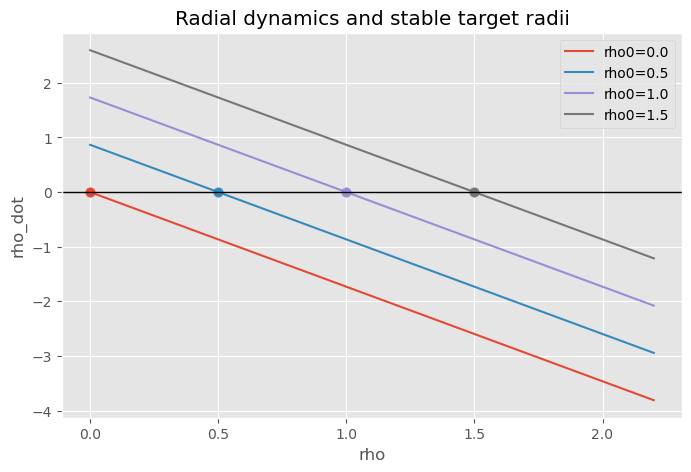

In [5]:
rho0_values = [0.0, 0.5, 1.0, 1.5]
rho = np.linspace(0, 2.2, 300)
M = 3.0

plt.figure(figsize=(8, 5))
for rho0 in rho0_values:
    rho_dot = -np.sqrt(M) * (rho - rho0)
    plt.plot(rho, rho_dot, label=f"rho0={rho0}")
    plt.scatter([rho0], [0], s=45)

plt.axhline(0, color="black", lw=1)
plt.xlabel("rho")
plt.ylabel("rho_dot")
plt.title("Radial dynamics and stable target radii")
plt.legend()
plt.show()

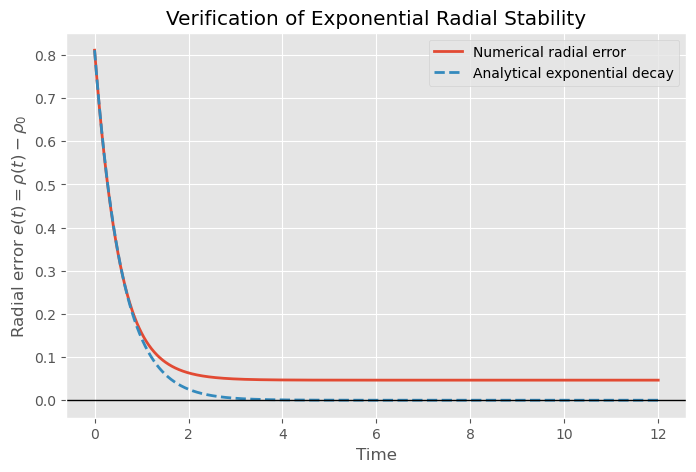

In [6]:
# Stability verification: numerical radial error vs analytical exponential decay

rho0 = 1.0
M = 3.0
R = 4.0
dt = 0.01
steps = 1200

x0 = (1.8, 0.2)
xs, _ = simulate_2d(x0, constant_params(rho0=rho0, M=M, R=R), dt=dt, steps=steps)

time = np.arange(steps + 1) * dt
rho = np.linalg.norm(xs, axis=1)
e_num = rho - rho0

e0 = e_num[0]
e_analytical = e0 * np.exp(-np.sqrt(M) * time)

plt.figure(figsize=(8, 5))
plt.plot(time, e_num, lw=2, label="Numerical radial error")
plt.plot(time, e_analytical, "--", lw=2, label="Analytical exponential decay")
plt.axhline(0, color="black", lw=1)
plt.xlabel("Time")
plt.ylabel(r"Radial error $e(t)=\rho(t)-\rho_0$")
plt.title("Verification of Exponential Radial Stability")
plt.legend()
plt.grid(True)
plt.show()

### 5.1 Lyapunov-Function Verification of Radial Stability

To make the stability connection more explicit, I used a Lyapunov-like function for the radial error. The radial dynamics of the paper's system are

$$
\dot{\rho}=-\sqrt{M}(\rho-\rho_0).
$$

Define the radial error as

$$
e=\rho-\rho_0.
$$

Then

$$
\dot{e}=-\sqrt{M}e.
$$

A natural Lyapunov function for this scalar error dynamics is

$$
V(e)=\frac{1}{2}e^2.
$$

Taking its time derivative along trajectories,

$$
\dot{V}=e\dot{e}.
$$

Substituting the error dynamics,

$$
\dot{V}=e(-\sqrt{M}e)
$$

$$
\dot{V}=-\sqrt{M}e^2 \leq 0.
$$

Therefore, the radial error decreases monotonically for \(M>0\). This is the same idea as Lyapunov's direct method from class: instead of only plotting trajectories, I check whether a positive quantity decreases along the motion.

For \(\rho_0=0\), this proves convergence to the point attractor at the origin. For \(\rho_0>0\), this proves convergence to the invariant circle

$$
\rho=\rho_0.
$$

So in this system, the Lyapunov function does not measure convergence to a point for every case. It measures convergence to the attracting radial set.

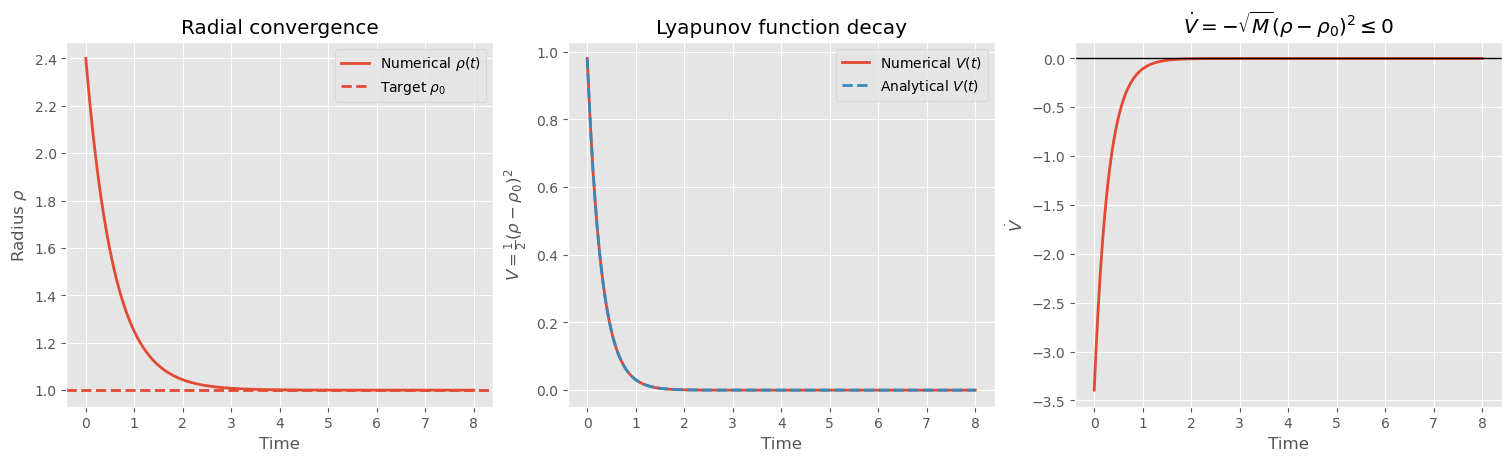

Lyapunov verification
---------------------
Initial radial error e(0)              : 1.400000
Final radial error e(tf)               : 1.343926e-06
Initial Lyapunov value V(0)            : 0.980000
Final Lyapunov value V(tf)             : 9.030681e-13
Maximum value of V_dot                 : -3.128320e-12
Number of numerical increases in V(t)  : 0


In [15]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


def paper_polar_rhs(t, z, rho0=1.0, M=3.0, R=4.0):
    """
    Paper DS in polar coordinates:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    rho, theta = z

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    return [rho_dot, theta_dot]


# Parameters for stability verification
rho0 = 1.0
M = 3.0
R = 4.0

rho_initial = 2.4
theta_initial = 0.25

t_end = 8.0
t_eval = np.linspace(0, t_end, 1200)

sol = solve_ivp(
    lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
    [0, t_end],
    [rho_initial, theta_initial],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

t = sol.t
rho = sol.y[0]
theta = sol.y[1]

# Radial error
e = rho - rho0

# Lyapunov function and its derivative
V = 0.5 * e**2
V_dot = -np.sqrt(M) * e**2

# Analytical error solution for comparison
e_analytical = e[0] * np.exp(-np.sqrt(M) * t)
V_analytical = 0.5 * e_analytical**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# Radius convergence
axes[0].plot(t, rho, lw=2, label=r"Numerical $\rho(t)$")
axes[0].axhline(rho0, ls="--", lw=2, label=r"Target $\rho_0$")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"Radius $\rho$")
axes[0].set_title("Radial convergence")
axes[0].legend()
axes[0].grid(True)

# Lyapunov function decay
axes[1].plot(t, V, lw=2, label=r"Numerical $V(t)$")
axes[1].plot(t, V_analytical, "--", lw=2, label=r"Analytical $V(t)$")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$V=\frac{1}{2}(\rho-\rho_0)^2$")
axes[1].set_title("Lyapunov function decay")
axes[1].legend()
axes[1].grid(True)

# V_dot
axes[2].plot(t, V_dot, lw=2)
axes[2].axhline(0, color="black", lw=1)
axes[2].set_xlabel("Time")
axes[2].set_ylabel(r"$\dot{V}$")
axes[2].set_title(r"$\dot{V}=-\sqrt{M}(\rho-\rho_0)^2 \leq 0$")
axes[2].grid(True)

plt.show()


# Numerical checks
num_positive_increases = np.sum(np.diff(V) > 1e-9)

print("Lyapunov verification")
print("---------------------")
print(f"Initial radial error e(0)              : {e[0]:.6f}")
print(f"Final radial error e(tf)               : {e[-1]:.6e}")
print(f"Initial Lyapunov value V(0)            : {V[0]:.6f}")
print(f"Final Lyapunov value V(tf)             : {V[-1]:.6e}")
print(f"Maximum value of V_dot                 : {np.max(V_dot):.6e}")
print(f"Number of numerical increases in V(t)  : {num_positive_increases}")

### My observation

The plot verifies the analytical stability result. The radius \(\rho(t)\) converges to the desired value \(\rho_0\), and the Lyapunov function

$$
V=\frac{1}{2}(\rho-\rho_0)^2
$$

decreases monotonically toward zero. The third plot also shows that

$$
\dot{V}\leq 0
$$

throughout the motion.

This helped me connect the paper's radial dynamics to the stability ideas from class. The system is designed so that the radial error behaves like a first-order stable system. The angular dynamics generate rotation, but the radial dynamics are responsible for attraction to the point or the limit cycle.

## 6. Phase Portraits: Point Attractor vs. Limit Cycle

The only parameter changed in the next experiment is `rho0`.

- `rho0 = 0`: the radius decays to zero, so the state converges to the center.
- `rho0 = 1`: the radius converges to one, so the trajectory approaches a closed orbit.

This directly connects to the class concepts of phase portraits, equilibria, and stable limit cycles.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


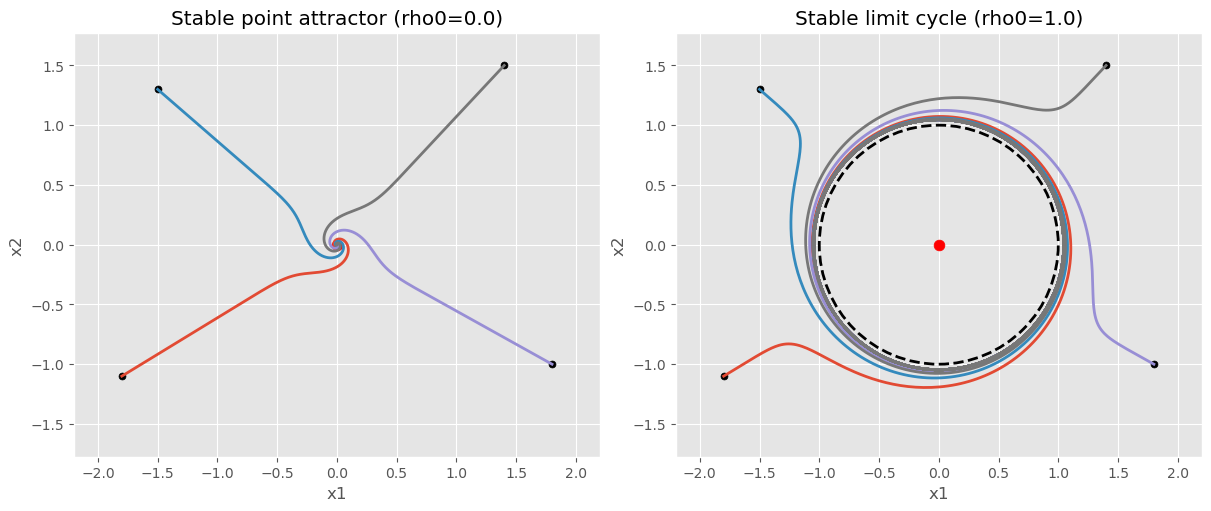

In [7]:
initial_conditions = [(-1.8, -1.1), (-1.5, 1.3), (1.8, -1.0), (1.4, 1.5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
cases = [(0.0, "Stable point attractor"), (1.0, "Stable limit cycle")]

for ax, (rho0, title) in zip(axes, cases):
    for x0 in initial_conditions:
        xs, _ = simulate_2d(x0, constant_params(rho0=rho0), steps=2500)
        ax.plot(xs[:, 0], xs[:, 1], lw=2)
        ax.scatter(xs[0, 0], xs[0, 1], c="black", s=25)
    if rho0 > 0:
        ax.add_patch(plt.Circle((0, 0), rho0, fill=False, color="black", ls="--", lw=2))
    ax.scatter(0, 0, c="red", s=60, label="center")
    ax.set_title(title + f" (rho0={rho0})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)

plt.show()

### 6.1 Numerical Comparison with the Van der Pol Limit Cycle

To connect the paper's dynamical system more directly with the course material, I compared it with the Van der Pol oscillator. In class, the Van der Pol oscillator was introduced as a non-conservative nonlinear oscillator that generates a stable limit cycle.

The Van der Pol oscillator is

$$
\ddot{x} + x - \epsilon(1-x^2)\dot{x}=0,
\qquad \epsilon > 0.
$$

Writing it as a first-order system,

$$
\dot{x}=y,
$$

$$
\dot{y}=-x+\epsilon(1-x^2)y.
$$

For small $\epsilon$, the method of averaging gives the slow-flow equation for the oscillation amplitude as

$$
\dot{A}=\frac{\epsilon A}{2}\left(1-\frac{A^2}{4}\right).
$$

This equation has equilibria at

$$
A=0, \qquad A=2.
$$

From the sign of $\dot{A}$, amplitudes smaller than 2 increase and amplitudes larger than 2 decrease. Therefore, $A=2$ is a stable limit-cycle amplitude. This is the same course idea of an attracting periodic orbit.

I added this comparison because the paper's model also creates a stable limit cycle, but in a more directly controlled way. In the Van der Pol oscillator, the limit-cycle amplitude emerges from nonlinear damping. In the paper's model, the final radius is prescribed directly using the parameter $\rho_0$:

$$
\rho^*=\rho_0.
$$

Therefore, the Van der Pol oscillator helps me understand the natural nonlinear-oscillator viewpoint, while the paper's model shows how the same limit-cycle idea can be redesigned for robot motion generation.

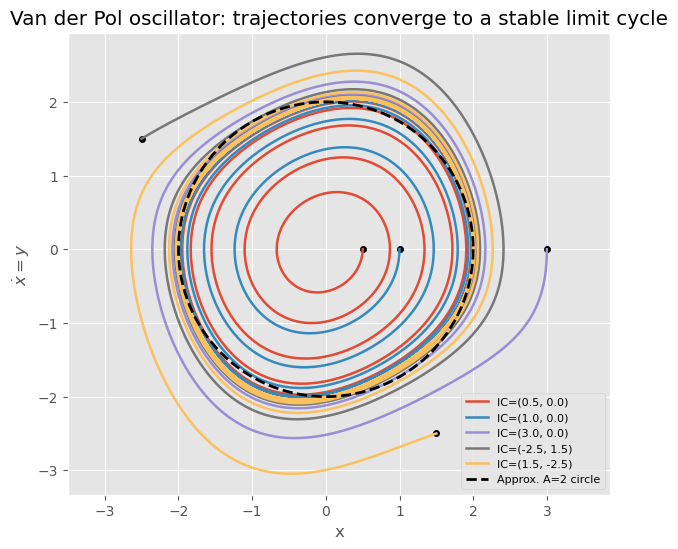

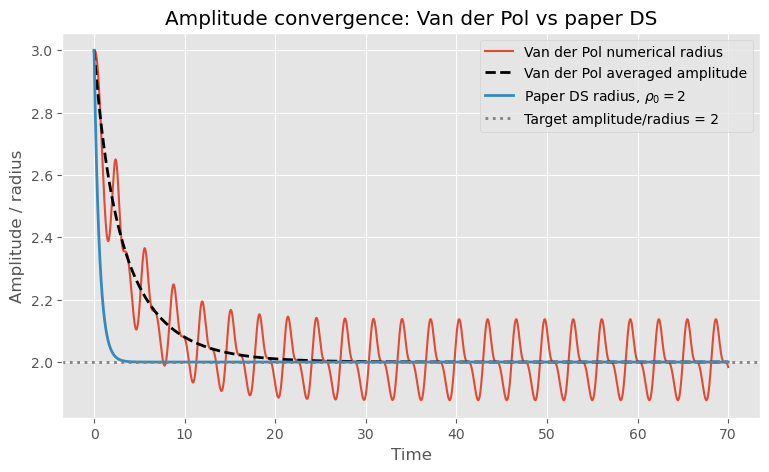

Numerical comparison
--------------------
epsilon used for Van der Pol              : 0.200
Van der Pol averaged stable amplitude     : 2.000
Van der Pol final mean numerical radius   : 2.004
Van der Pol final mean averaged amplitude : 2.000
Paper DS prescribed stable radius rho0    : 2.000
Paper DS final mean numerical radius      : 2.000

Paper DS radius error check
---------------------------
Final radius error                 : 4.946576e-11
Mean radius error over final 20%    : 3.459331e-11
Maximum absolute final-20% error    : 2.978586e-10


In [14]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Van der Pol oscillator
# ============================================================

def vdp_rhs(t, z, eps=0.2):
    """
    Van der Pol oscillator:
        x_dot = y
        y_dot = -x + eps*(1 - x^2)*y
    """
    x, y = z
    return [y, -x + eps * (1 - x**2) * y]


def simulate_vdp(z0, eps=0.2, t_end=60.0, n=6000):
    t_eval = np.linspace(0, t_end, n)

    sol = solve_ivp(
        lambda t, z: vdp_rhs(t, z, eps),
        [0, t_end],
        z0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11
    )

    return sol.t, sol.y.T


def averaged_vdp_amplitude(t, B, eps=0.2):
    """
    Averaged amplitude solution for Van der Pol:
        A_dot = eps*A/2 * (1 - A^2/4)

    If A(0)=B, then:
        A^2 = 4*exp(eps*t) / (4/B^2 - 1 + exp(eps*t))
    """
    return np.sqrt(
        4 * np.exp(eps * t) /
        ((4 / B**2) - 1 + np.exp(eps * t))
    )


# ============================================================
# Paper DS integrated directly in polar coordinates
# This removes the artificial steady-state radius error caused
# by Forward Euler integration in Cartesian coordinates.
# ============================================================

def paper_polar_rhs(t, z, rho0=2.0, M=3.0, R=4.0):
    """
    Paper DS in polar coordinates:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    rho, theta = z

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    return [rho_dot, theta_dot]


def simulate_paper_polar(x0, rho0=2.0, M=3.0, R=4.0, t_eval=None):
    """
    Simulates the paper DS in polar coordinates using solve_ivp,
    then converts the result back to Cartesian coordinates.
    """
    x0 = np.asarray(x0, dtype=float)

    rho_init = np.linalg.norm(x0)
    theta_init = np.arctan2(x0[1], x0[0])

    sol = solve_ivp(
        lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
        [t_eval[0], t_eval[-1]],
        [rho_init, theta_init],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )

    rho = sol.y[0]
    theta = sol.y[1]

    xs = np.column_stack([
        rho * np.cos(theta),
        rho * np.sin(theta)
    ])

    return xs, rho


# ============================================================
# 1) Phase portrait comparison: Van der Pol stable limit cycle
# ============================================================

eps = 0.2

initial_conditions_vdp = [
    (0.5, 0.0),
    (1.0, 0.0),
    (3.0, 0.0),
    (-2.5, 1.5),
    (1.5, -2.5)
]

plt.figure(figsize=(7, 6))

for z0_ic in initial_conditions_vdp:
    t_vdp_ic, z_vdp_ic = simulate_vdp(z0_ic, eps=eps, t_end=70.0)
    plt.plot(z_vdp_ic[:, 0], z_vdp_ic[:, 1], lw=1.8, label=f"IC={z0_ic}")
    plt.scatter(z_vdp_ic[0, 0], z_vdp_ic[0, 1], c="black", s=20)

# Approximate averaged limit-cycle radius A = 2 for small epsilon
theta_grid = np.linspace(0, 2*np.pi, 400)
plt.plot(
    2*np.cos(theta_grid),
    -2*np.sin(theta_grid),
    "k--",
    lw=2,
    label="Approx. A=2 circle"
)

plt.xlabel("x")
plt.ylabel(r"$\dot{x}=y$")
plt.title("Van der Pol oscillator: trajectories converge to a stable limit cycle")
plt.axis("equal")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()


# ============================================================
# 2) Amplitude/radius comparison:
#    Van der Pol vs paper's Hopf-inspired DS
# ============================================================

z0 = (3.0, 0.0)
B = np.linalg.norm(z0)

t_vdp, z_vdp = simulate_vdp(z0, eps=eps, t_end=70.0)
A_num_vdp = np.linalg.norm(z_vdp, axis=1)
A_avg_vdp = averaged_vdp_amplitude(t_vdp, B=B, eps=eps)

# Paper DS with rho0 = 2, matching the averaged Van der Pol limit-cycle amplitude
rho0_compare = 2.0
M_compare = 3.0
R_compare = 4.0

xs_paper, rho_paper = simulate_paper_polar(
    z0,
    rho0=rho0_compare,
    M=M_compare,
    R=R_compare,
    t_eval=t_vdp
)

plt.figure(figsize=(9, 5))

plt.plot(t_vdp, A_num_vdp, lw=1.5, label="Van der Pol numerical radius")
plt.plot(t_vdp, A_avg_vdp, "k--", lw=2, label="Van der Pol averaged amplitude")
plt.plot(t_vdp, rho_paper, lw=2, label=r"Paper DS radius, $\rho_0=2$")
plt.axhline(2.0, color="gray", ls=":", lw=2, label="Target amplitude/radius = 2")

plt.xlabel("Time")
plt.ylabel("Amplitude / radius")
plt.title("Amplitude convergence: Van der Pol vs paper DS")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 3) Numerical summary table
# ============================================================

vdp_final_mean_radius = np.mean(A_num_vdp[int(0.8 * len(A_num_vdp)):])
vdp_final_mean_avg_amp = np.mean(A_avg_vdp[int(0.8 * len(A_avg_vdp)):])
paper_final_mean_radius = np.mean(rho_paper[int(0.8 * len(rho_paper)):])

print("Numerical comparison")
print("--------------------")
print(f"epsilon used for Van der Pol              : {eps:.3f}")
print(f"Van der Pol averaged stable amplitude     : {2.000:.3f}")
print(f"Van der Pol final mean numerical radius   : {vdp_final_mean_radius:.3f}")
print(f"Van der Pol final mean averaged amplitude : {vdp_final_mean_avg_amp:.3f}")
print(f"Paper DS prescribed stable radius rho0    : {rho0_compare:.3f}")
print(f"Paper DS final mean numerical radius      : {paper_final_mean_radius:.3f}")


# ============================================================
# 4) Optional: check final radius error of the paper DS
# ============================================================

paper_radius_error = rho_paper - rho0_compare

print()
print("Paper DS radius error check")
print("---------------------------")
print(f"Final radius error                 : {paper_radius_error[-1]:.6e}")
print(f"Mean radius error over final 20%    : {np.mean(paper_radius_error[int(0.8 * len(paper_radius_error)):]):.6e}")
print(f"Maximum absolute final-20% error    : {np.max(np.abs(paper_radius_error[int(0.8 * len(paper_radius_error)):])):.6e}")

### 6.2 Cycle-by-Cycle Radius Check for the Stable Limit Cycle

The phase portrait visually shows that trajectories approach a closed orbit, but I wanted a more numerical way to verify that the limit cycle is attracting. For this, I used a Poincaré-type section.

For the paper's 2D system, I selected the section

$$
y=0, \qquad x>0.
$$

This corresponds to the trajectory crossing the positive \(x\)-axis once per rotation. At each crossing, I recorded the radius

$$
\rho_n.
$$

If the closed orbit is stable, then the sequence of crossing radii should converge to

$$
\rho_n \rightarrow \rho_0.
$$

This is a numerical return-map test. Instead of only saying that the trajectory spirals toward the limit cycle, I check whether the sampled radius at every cycle approaches the target radius.

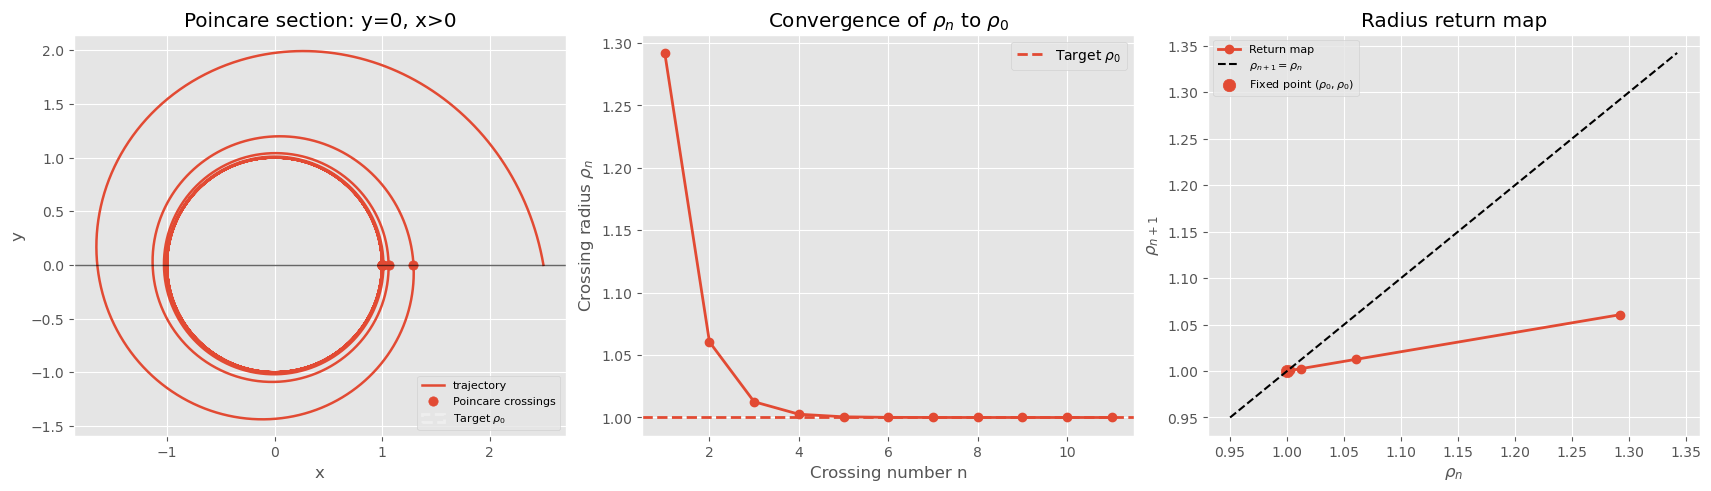

Poincare return-map verification
--------------------------------
Number of crossings detected              : 11
First crossing radius rho_1               : 1.292122
Last crossing radius rho_N                : 1.000000
Target radius rho0                        : 1.000000
Final crossing error rho_N - rho0         : 4.392052e-08
Maximum absolute crossing error           : 0.292122
Final absolute crossing error             : 4.392052e-08


In [16]:
# ------------------------------------------------------------
# Poincare return map / radius return plot for the paper DS
# ------------------------------------------------------------

rho0 = 1.0
M = 0.25      # Smaller M makes convergence slower, so the return map is easier to see
R = 2.0

rho_initial = 2.5
theta_initial = 0.0

t_end = 35.0
t_eval = np.linspace(0, t_end, 9000)

sol = solve_ivp(
    lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
    [0, t_end],
    [rho_initial, theta_initial],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

t = sol.t
rho = sol.y[0]
theta_unwrapped = sol.y[1]

# Convert to Cartesian for plotting
x = rho * np.cos(theta_unwrapped)
y = rho * np.sin(theta_unwrapped)

# Poincare section: y = 0, x > 0
# In polar coordinates this corresponds to theta = 2*pi*n.
max_crossing_index = int(theta_unwrapped[-1] // (2*np.pi))
crossing_angles = 2 * np.pi * np.arange(1, max_crossing_index + 1)

# Interpolate rho at every crossing angle
rho_crossings = np.interp(crossing_angles, theta_unwrapped, rho)

# Cartesian crossing points
x_crossings = rho_crossings * np.cos(crossing_angles)
y_crossings = rho_crossings * np.sin(crossing_angles)

crossing_number = np.arange(1, len(rho_crossings) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

# 1) Phase portrait with Poincare crossings
axes[0].plot(x, y, lw=1.8, label="trajectory")
axes[0].scatter(x_crossings, y_crossings, s=45, label="Poincare crossings")
axes[0].add_patch(plt.Circle((0, 0), rho0, fill=False, ls="--", lw=2, label=r"Target $\rho_0$"))
axes[0].axhline(0, color="black", lw=1, alpha=0.6)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Poincare section: y=0, x>0")
axes[0].axis("equal")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# 2) Radius at each crossing
axes[1].plot(crossing_number, rho_crossings, marker="o", lw=2)
axes[1].axhline(rho0, ls="--", lw=2, label=r"Target $\rho_0$")
axes[1].set_xlabel("Crossing number n")
axes[1].set_ylabel(r"Crossing radius $\rho_n$")
axes[1].set_title(r"Convergence of $\rho_n$ to $\rho_0$")
axes[1].legend()
axes[1].grid(True)

# 3) Return map rho_{n+1} vs rho_n
rho_n = rho_crossings[:-1]
rho_np1 = rho_crossings[1:]

axes[2].plot(rho_n, rho_np1, marker="o", lw=2, label=r"Return map")
min_r = min(np.min(rho_n), np.min(rho_np1), rho0) - 0.05
max_r = max(np.max(rho_n), np.max(rho_np1), rho0) + 0.05
axes[2].plot([min_r, max_r], [min_r, max_r], "k--", lw=1.5, label=r"$\rho_{n+1}=\rho_n$")
axes[2].scatter([rho0], [rho0], s=80, label=r"Fixed point $(\rho_0,\rho_0)$")
axes[2].set_xlabel(r"$\rho_n$")
axes[2].set_ylabel(r"$\rho_{n+1}$")
axes[2].set_title("Radius return map")
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.show()


# Numerical summary
print("Poincare return-map verification")
print("--------------------------------")
print(f"Number of crossings detected              : {len(rho_crossings)}")
print(f"First crossing radius rho_1               : {rho_crossings[0]:.6f}")
print(f"Last crossing radius rho_N                : {rho_crossings[-1]:.6f}")
print(f"Target radius rho0                        : {rho0:.6f}")
print(f"Final crossing error rho_N - rho0         : {rho_crossings[-1] - rho0:.6e}")
print(f"Maximum absolute crossing error           : {np.max(np.abs(rho_crossings - rho0)):.6f}")
print(f"Final absolute crossing error             : {abs(rho_crossings[-1] - rho0):.6e}")

## 7. Bifurcation-Like Parameter Sweep

A bifurcation diagram summarizes how stable long-term behavior changes with a parameter. In this Hopf-inspired system, the stable radial set is

$$
\rho^*=\rho_0.
$$

So the attracting set is a point when `rho0 = 0`, and a circle when `rho0 > 0`. The plot below is simple, but conceptually it plays the role of a bifurcation diagram: varying `rho0` changes the qualitative nature of the phase portrait.

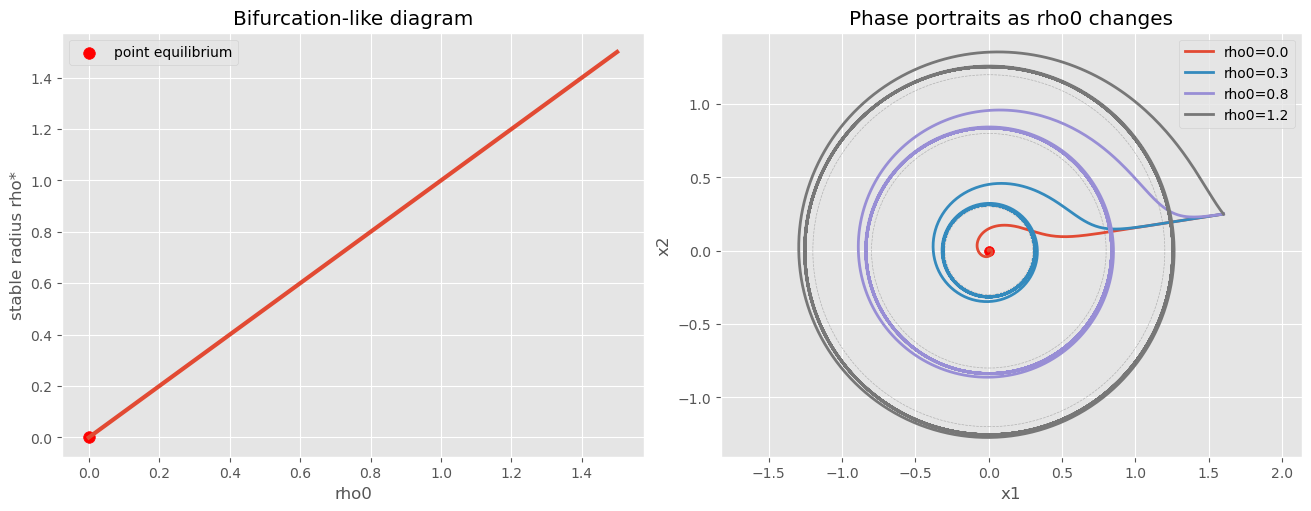

In [8]:
rho0_grid = np.linspace(0, 1.5, 100)
stable_radius = rho0_grid

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(rho0_grid, stable_radius, lw=3)
axes[0].scatter([0], [0], c="red", s=70, label="point equilibrium")
axes[0].set_xlabel("rho0")
axes[0].set_ylabel("stable radius rho*")
axes[0].set_title("Bifurcation-like diagram")
axes[0].legend()

for rho0 in [0.0, 0.3, 0.8, 1.2]:
    xs, _ = simulate_2d((1.6, 0.25), constant_params(rho0=rho0), steps=1800)
    axes[1].plot(xs[:, 0], xs[:, 1], lw=2, label=f"rho0={rho0}")
    if rho0 > 0:
        axes[1].add_patch(plt.Circle((0, 0), rho0, fill=False, color="gray", ls="--", alpha=0.5))

axes[1].scatter(0, 0, c="red", s=50)
axes[1].axis("equal")
axes[1].set_title("Phase portraits as rho0 changes")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].legend()
plt.show()

## 8. Effect of Parameters `M`, `R`, and `rho0`

The paper emphasizes interpretable parameters. In this implementation:

- Increasing `rho0` increases the final orbit radius.
- Increasing `M` increases radial convergence speed.
- Changing the sign of `R` changes rotation direction.

This is important for robotics because the same learned DS can be reused while the user changes speed, amplitude, center, and direction.

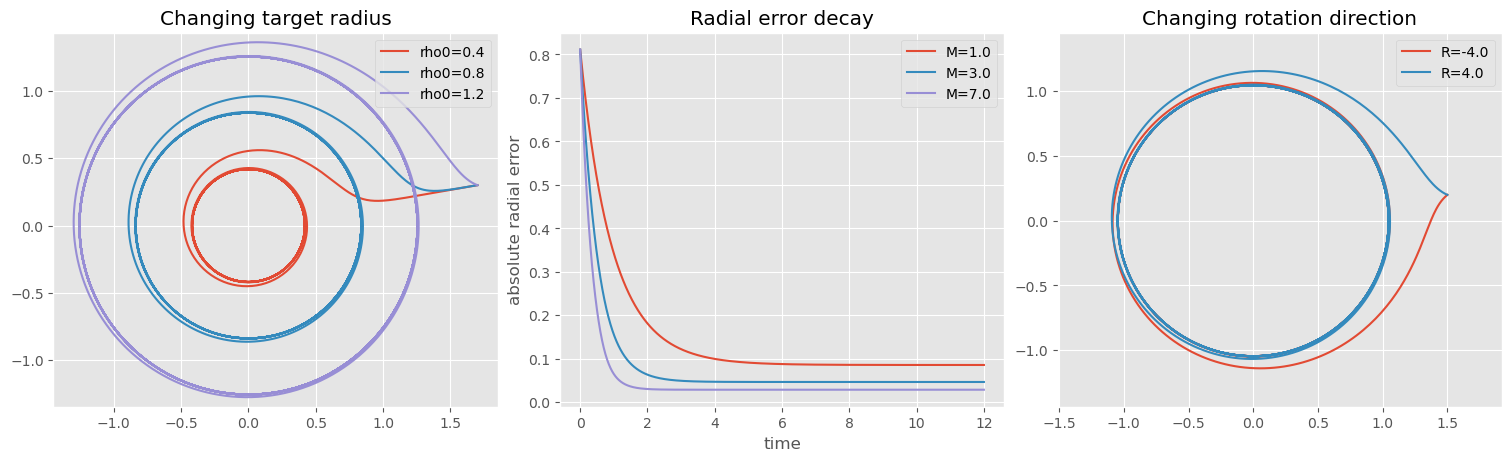

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for rho0 in [0.4, 0.8, 1.2]:
    xs, _ = simulate_2d((1.7, 0.3), constant_params(rho0=rho0, M=3.0, R=4.0), steps=1800)
    axes[0].plot(xs[:, 0], xs[:, 1], label=f"rho0={rho0}")
axes[0].axis("equal")
axes[0].set_title("Changing target radius")
axes[0].legend()

for M_val in [1.0, 3.0, 7.0]:
    xs, _ = simulate_2d((1.8, 0.2), constant_params(rho0=1.0, M=M_val, R=4.0), steps=1200)
    radius_error = np.linalg.norm(xs, axis=1) - 1.0
    axes[1].plot(np.arange(len(xs)) * 0.01, np.abs(radius_error), label=f"M={M_val}")
axes[1].set_title("Radial error decay")
axes[1].set_xlabel("time")
axes[1].set_ylabel("absolute radial error")
axes[1].legend()

for R_val in [-4.0, 4.0]:
    xs, _ = simulate_2d((1.5, 0.2), constant_params(rho0=1.0, M=3.0, R=R_val), steps=1000)
    axes[2].plot(xs[:, 0], xs[:, 1], label=f"R={R_val}")
axes[2].axis("equal")
axes[2].set_title("Changing rotation direction")
axes[2].legend()

plt.show()

## 9. Smooth Parameter Switching vs. Hard Switching

The paper's practical motivation is that switching between separate DSs can create abrupt transients. In a switched system, the vector field can change discontinuously at the switching time.

Here we compare two cases:

- **Hard switching:** use a linear reaching controller, then suddenly switch to the limit-cycle DS.
- **Smooth parameter switching:** keep the same DS structure and smoothly ramp `rho0` from 0 to 1.

This connects directly to switched systems, discontinuity in vector fields, smooth transitions, and robustness.

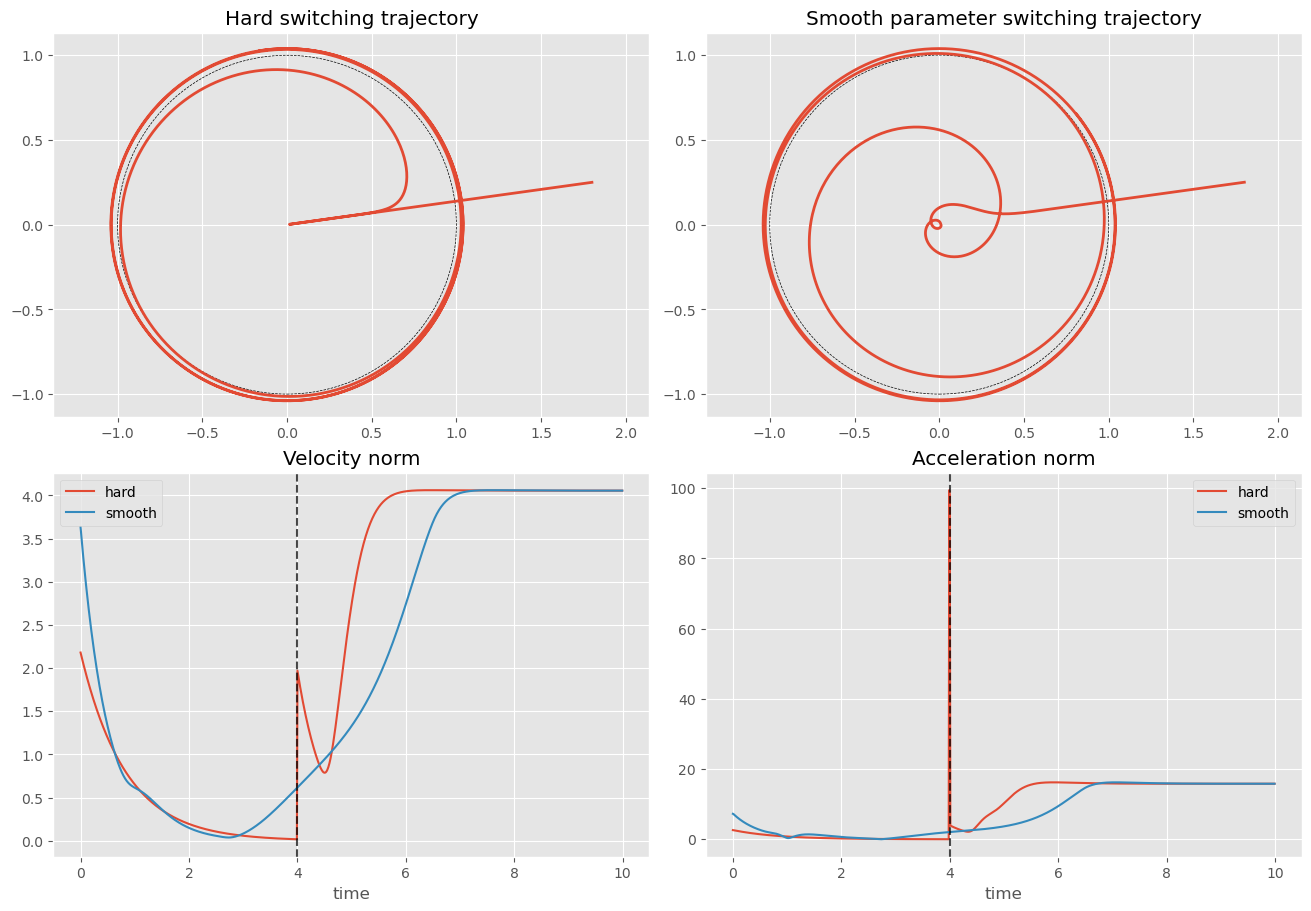

In [10]:
def linear_reach(x, goal=(0.0, 0.0), k=2.0):
    return -k * (np.asarray(x) - np.asarray(goal))


def smoothstep(s):
    s = np.clip(s, 0.0, 1.0)
    return s * s * (3.0 - 2.0 * s)


def simulate_hard_switch(x0, switch_time=4.0, dt=0.01, steps=1000):
    xs = np.zeros((steps + 1, 2))
    vs = np.zeros((steps, 2))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        t = k * dt
        if t < switch_time:
            vs[k] = linear_reach(xs[k], goal=(0.0, 0.0), k=1.2)
        else:
            vs[k] = ds_2d(xs[k], rho0=1.0, M=4.0, R=4.0)
        xs[k + 1] = xs[k] + dt * vs[k]
    return xs, vs


def smooth_switch_params(t):
    ramp = smoothstep((t - 2.5) / 4.0)
    return {"rho0": ramp, "M": 4.0, "R": 4.0, "center": (0.0, 0.0)}


dt = 0.01
steps = 1000
x0 = (1.8, 0.25)
hard_xs, hard_vs = simulate_hard_switch(x0, dt=dt, steps=steps)
smooth_xs, smooth_vs = simulate_2d(x0, smooth_switch_params, dt=dt, steps=steps)
time = np.arange(steps) * dt

hard_acc = np.gradient(hard_vs, dt, axis=0)
smooth_acc = np.gradient(smooth_vs, dt, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

axes[0, 0].plot(hard_xs[:, 0], hard_xs[:, 1], lw=2)
axes[0, 0].add_patch(plt.Circle((0, 0), 1.0, fill=False, color="black", ls="--"))
axes[0, 0].set_title("Hard switching trajectory")
axes[0, 0].axis("equal")

axes[0, 1].plot(smooth_xs[:, 0], smooth_xs[:, 1], lw=2)
axes[0, 1].add_patch(plt.Circle((0, 0), 1.0, fill=False, color="black", ls="--"))
axes[0, 1].set_title("Smooth parameter switching trajectory")
axes[0, 1].axis("equal")

axes[1, 0].plot(time, np.linalg.norm(hard_vs, axis=1), label="hard")
axes[1, 0].plot(time, np.linalg.norm(smooth_vs, axis=1), label="smooth")
axes[1, 0].axvline(4.0, color="black", ls="--", alpha=0.7)
axes[1, 0].set_title("Velocity norm")
axes[1, 0].set_xlabel("time")
axes[1, 0].legend()

axes[1, 1].plot(time, np.linalg.norm(hard_acc, axis=1), label="hard")
axes[1, 1].plot(time, np.linalg.norm(smooth_acc, axis=1), label="smooth")
axes[1, 1].axvline(4.0, color="black", ls="--", alpha=0.7)
axes[1, 1].set_title("Acceleration norm")
axes[1, 1].set_xlabel("time")
axes[1, 1].legend()

plt.show()

In the hard-switching case, the vector field changes discontinuously at the switching time. This can create sharp changes in velocity and acceleration. In the parameter-varying case, the same dynamical-system structure is retained and only `rho0` changes smoothly. This mirrors the paper's robotic wiping experiment, where transitions inside one learned DS are smoother than switching between separate controllers.

## 10. Extension to 3D Planar Limit Cycles

The paper extends the idea to 3D using spherical-coordinate reasoning:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\phi} = -\sqrt{M}\phi,
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

The elevation angle decays, so the motion settles onto a plane while the radial dynamics create either a point attractor or a planar limit cycle.

The simulation below is a simplified 3D demonstration of planar limit-cycle convergence. The full paper uses spherical-coordinate reasoning and PCA to orient the cycle plane in 3D.

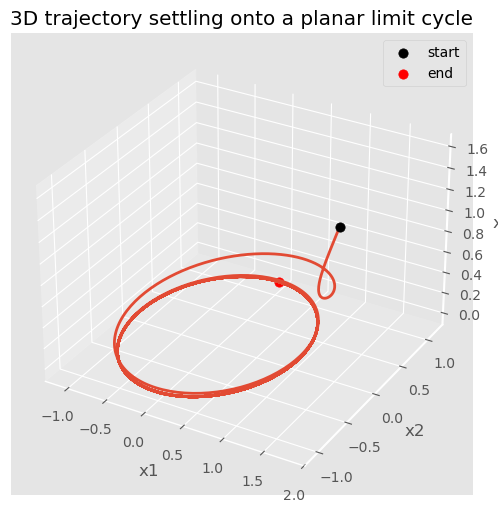

In [11]:
def simulate_3d(x0, rho0=1.0, M=3.0, R=4.0, dt=0.01, steps=3000):
    xs = np.zeros((steps + 1, 3))
    xs[0] = np.asarray(x0, dtype=float)
    sqrt_M = np.sqrt(M)

    for k in range(steps):
        x, y, z = xs[k]
        rho_xy = np.hypot(x, y)

        if rho_xy < 1e-9:
            radial_xy = np.array([1.0, 0.0])
        else:
            radial_xy = np.array([x, y]) / rho_xy

        tangent_xy = np.array([-radial_xy[1], radial_xy[0]])
        rho_dot = -sqrt_M * (rho_xy - rho0)
        theta_dot = R * np.exp(-(M**2) * (rho_xy - rho0) ** 2)
        xy_dot = rho_dot * radial_xy + rho_xy * theta_dot * tangent_xy
        z_dot = -sqrt_M * z

        xs[k + 1] = xs[k] + dt * np.array([xy_dot[0], xy_dot[1], z_dot])

    return xs


xs3 = simulate_3d((1.8, -0.4, 1.6), rho0=1.0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(xs3[:, 0], xs3[:, 1], xs3[:, 2], lw=2)
ax.scatter(xs3[0, 0], xs3[0, 1], xs3[0, 2], c="black", s=45, label="start")
ax.scatter(xs3[-1, 0], xs3[-1, 1], xs3[-1, 2], c="red", s=45, label="end")
ax.set_title("3D trajectory settling onto a planar limit cycle")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.legend()
plt.show()

## 14. Conclusion

Khadivar, Lauzana, and Billard propose a Hopf-inspired dynamical-system framework that unifies point-to-point and rhythmic robot motions. By changing a small number of interpretable parameters, the same system can move between a stable equilibrium and a stable limit cycle. The simulations in this notebook reproduce the central mechanism, analyze its stability, visualize its bifurcation-like parameter sweep, compare smooth parameter modulation against hard switching, and show a small parameter-learning experiment from synthetic demonstration data.